In [24]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

print("🚀 INICIANDO PIPELINE DE DATOS: FASE 1 (Carga y Filtrado Base)")

# 1. Definimos las columnas estrictamente necesarias
columnas_tfg = [
    'TAIL_NUMBER', 'FLIGHTDATE', 'CRSDEPTIME', 'CRSARRTIME', 'ARRDELAY', 'ARRDEL15',
    'MONTH', 'DAYOFWEEK', 'REPORTING_AIRLINE', 'ORIGIN', 'DEST', 'DISTANCE', 
    'DEPTIME', 'DEPDELAY', 'TAXIOUT', 'TAXIIN', 'ARRTIME', 'ACTUALELAPSEDTIME', 
    'CRSELAPSEDTIME', 'CARRIERDELAY', 'WEATHERDELAY', 'NASDELAY', 'SECURITYDELAY', 
    'LATEAIRCRAFTDELAY', 'CANCELLED', 'DIVERTED'
]

ruta_carpeta = '/Users/manuelgonzalez/Documents/Datos crudos TFG' 
archivos_csv = glob.glob(os.path.join(ruta_carpeta, "*.csv"))

if not archivos_csv:
    raise ValueError(f"❌ ERROR: No se encontraron archivos CSV en {ruta_carpeta}")

df_lista = []

for f in archivos_csv:
    print(f"Cargando: {os.path.basename(f)}...")
    temp_df = pd.read_csv(f, usecols=lambda x: x.strip().upper() in columnas_tfg, low_memory=False)
    temp_df.columns = temp_df.columns.str.strip().str.upper()
    
    # Filtramos: Solo vuelos operados Y con matrícula asignada
    temp_df = temp_df[
        (temp_df['CANCELLED'] == 0) & 
        (temp_df['DIVERTED'] == 0) & 
        (temp_df['TAIL_NUMBER'].notna())
    ]
    temp_df = temp_df.drop(columns=['CANCELLED', 'DIVERTED'])
    df_lista.append(temp_df)

df_total = pd.concat(df_lista, ignore_index=True)
print(f"✅ PASO 1 COMPLETADO: Extracción finalizada. Filas: {df_total.shape[0]}")

🚀 INICIANDO PIPELINE DE DATOS: FASE 1 (Carga y Filtrado Base)
Cargando: Datos_de_Marzo.csv...
Cargando: Datos_de_Mayo.csv...
Cargando: Datos_de_Abril.csv...
Cargando: Datos_de_Junio.csv...
Cargando: Datos_de_Febrero.csv...
Cargando: Datos_de_Enero.csv...
✅ PASO 1 COMPLETADO: Extracción finalizada. Filas: 3403465


In [25]:
print("\n⏱️ FORJANDO LA LÍNEA TEMPORAL...")
antes = df_total.shape[0]
df_total = df_total.dropna(subset=['CRSDEPTIME', 'DEPDELAY', 'CRSELAPSEDTIME', 'ACTUALELAPSEDTIME']).copy()

df_total['FLIGHTDATE'] = pd.to_datetime(df_total['FLIGHTDATE'])
horas_prog = (df_total['CRSDEPTIME'] // 100).replace(24, 0)
mins_prog = df_total['CRSDEPTIME'] % 100

df_total['SCHED_DEP'] = df_total['FLIGHTDATE'] + pd.to_timedelta(horas_prog, unit='h') + pd.to_timedelta(mins_prog, unit='m')
df_total['FULL_DATETIME_DEP'] = df_total['SCHED_DEP'] + pd.to_timedelta(df_total['DEPDELAY'], unit='m')
df_total['SCHED_ARR'] = df_total['SCHED_DEP'] + pd.to_timedelta(df_total['CRSELAPSEDTIME'], unit='m')
df_total['FULL_DATETIME_ARR'] = df_total['FULL_DATETIME_DEP'] + pd.to_timedelta(df_total['ACTUALELAPSEDTIME'], unit='m')

df_total = df_total.drop(columns=['CRSDEPTIME', 'CRSARRTIME', 'DEPTIME', 'ARRTIME'])
print("✅ LÍNEA TEMPORAL CREADA.")


⏱️ FORJANDO LA LÍNEA TEMPORAL...
✅ LÍNEA TEMPORAL CREADA.


In [26]:
print("\n🛡️ INICIANDO MOTOR DE DOMINÓ (Rotaciones y Herencia)...")
df_total = df_total.sort_values(by=['TAIL_NUMBER', 'FULL_DATETIME_DEP']).reset_index(drop=True)

prev_tail = df_total['TAIL_NUMBER'].shift(1)
prev_dest = df_total['DEST'].shift(1)
prev_arr_real = df_total['FULL_DATETIME_ARR'].shift(1)
prev_arr_prog = df_total['SCHED_ARR'].shift(1)
prev_retraso = df_total['ARRDELAY'].shift(1)

mismo_avion = (df_total['TAIL_NUMBER'] == prev_tail)
ruta_logica = (df_total['ORIGIN'] == prev_dest) 
df_total['GAP_REAL_SUELO_H'] = (df_total['FULL_DATETIME_DEP'] - prev_arr_real).dt.total_seconds() / 3600
rotacion_viva = mismo_avion & ruta_logica & (df_total['GAP_REAL_SUELO_H'] > 0) & (df_total['GAP_REAL_SUELO_H'] <= 12)

peso_herencia = np.exp(-df_total['GAP_REAL_SUELO_H'] / 2)
herencia_calculada = np.where(prev_retraso > 0, prev_retraso * peso_herencia, prev_retraso)

df_total['RETRASO_HEREDADO_REAL'] = pd.Series(herencia_calculada).where(rotacion_viva, np.nan)
df_total['TIEMPO_TIERRA_PROG'] = ((df_total['SCHED_DEP'] - prev_arr_prog).dt.total_seconds() / 60).where(rotacion_viva, np.nan)
df_total['MARGEN_OPERATIVO_NETO'] = df_total['TIEMPO_TIERRA_PROG'] - df_total['RETRASO_HEREDADO_REAL']

df_total.drop(columns=['GAP_REAL_SUELO_H'], inplace=True, errors='ignore')
print("✅ FASE DE DOMINÓ COMPLETADA.")


🛡️ INICIANDO MOTOR DE DOMINÓ (Rotaciones y Herencia)...


/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arraylike.py:397: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


✅ FASE DE DOMINÓ COMPLETADA.


In [27]:
df_total.head(30)

,MONTH,DAYOFWEEK,FLIGHTDATE,REPORTING_AIRLINE,TAIL_NUMBER,ORIGIN,DEST,DEPDELAY,TAXIOUT,TAXIIN,...,NASDELAY,SECURITYDELAY,LATEAIRCRAFTDELAY,SCHED_DEP,FULL_DATETIME_DEP,SCHED_ARR,FULL_DATETIME_ARR,RETRASO_HEREDADO_REAL,TIEMPO_TIERRA_PROG,MARGEN_OPERATIVO_NETO
0,1,7,2024-01-28,G4,188NV,FLL,CVG,353.0,11.0,10.0,...,0.0,0.0,0.0,2024-01-28 17:18:00,2024-01-28 23:11:00,2024-01-28 19:59:00,2024-01-29 01:45:00,NaN,NaN,NaN
1,2,4,2024-02-01,G4,188NV,CVG,SRQ,-8.0,26.0,5.0,...,NaN,NaN,NaN,2024-02-01 10:00:00,2024-02-01 09:52:00,2024-02-01 12:25:00,2024-02-01 12:19:00,NaN,NaN,NaN
2,2,4,2024-02-01,G4,188NV,SRQ,CVG,-3.0,20.0,4.0,...,NaN,NaN,NaN,2024-02-01 13:15:00,2024-02-01 13:12:00,2024-02-01 15:33:00,2024-02-01 15:30:00,-6.000000,50.0,56.000000
3,2,5,2024-02-02,G4,188NV,CVG,PGD,-9.0,15.0,7.0,...,NaN,NaN,NaN,2024-02-02 07:30:00,2024-02-02 07:21:00,2024-02-02 09:56:00,2024-02-02 09:34:00,NaN,NaN,NaN
4,2,5,2024-02-02,G4,188NV,PGD,CVG,-15.0,12.0,4.0,...,NaN,NaN,NaN,2024-02-02 10:46:00,2024-02-02 10:31:00,2024-02-02 13:08:00,2024-02-02 12:49:00,-22.000000,50.0,72.000000
5,2,5,2024-02-02,G4,188NV,CVG,FLL,-8.0,12.0,7.0,...,NaN,NaN,NaN,2024-02-02 13:58:00,2024-02-02 13:50:00,2024-02-02 16:40:00,2024-02-02 16:05:00,-19.000000,50.0,69.000000
6,2,5,2024-02-02,G4,188NV,FLL,CVG,-7.0,21.0,5.0,...,NaN,NaN,NaN,2024-02-02 17:30:00,2024-02-02 17:23:00,2024-02-02 20:06:00,2024-02-02 19:58:00,-35.000000,50.0,85.000000
7,2,7,2024-02-04,G4,188NV,CVG,SFB,-7.0,14.0,10.0,...,NaN,NaN,NaN,2024-02-04 12:29:00,2024-02-04 12:22:00,2024-02-04 14:40:00,2024-02-04 14:35:00,NaN,NaN,NaN
8,2,7,2024-02-04,G4,188NV,SFB,TYS,2.0,26.0,4.0,...,NaN,NaN,NaN,2024-02-04 15:30:00,2024-02-04 15:32:00,2024-02-04 17:13:00,2024-02-04 17:09:00,-5.000000,50.0,55.000000
9,2,7,2024-02-04,G4,188NV,TYS,SFB,7.0,14.0,4.0,...,39.0,0.0,0.0,2024-02-04 18:03:00,2024-02-04 18:10:00,2024-02-04 19:46:00,2024-02-04 20:32:00,-4.000000,50.0,54.000000


📊 AUDITORÍA: DIAGNÓSTICO VISUAL (ANTES DE LA QUEMA)


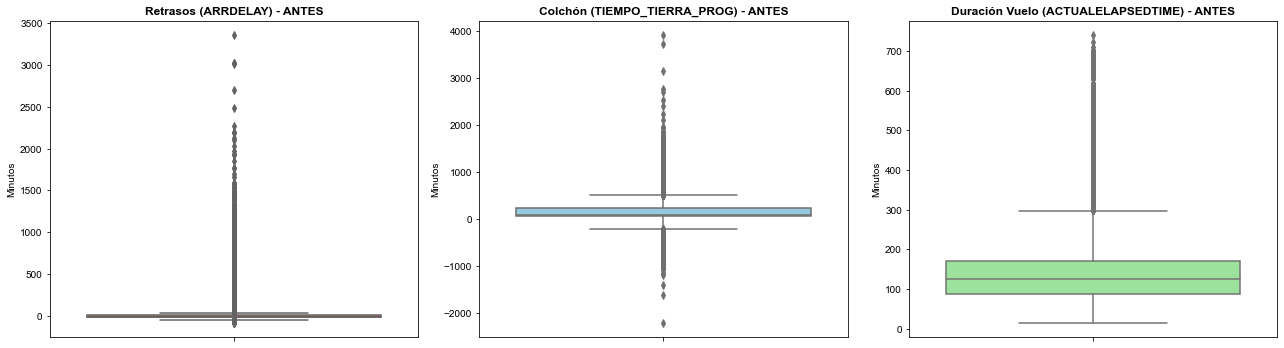

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 AUDITORÍA: DIAGNÓSTICO VISUAL (ANTES DE LA QUEMA)")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_theme(style="whitegrid")

# Gráfico 1: Retrasos Crudos
sns.boxplot(y=df_total['ARRDELAY'], ax=axes[0], color='tomato')
axes[0].set_title('Retrasos (ARRDELAY) - ANTES', fontweight='bold')
axes[0].set_ylabel('Minutos')

# Gráfico 2: Colchón de Tierra Crudo
sns.boxplot(y=df_total['TIEMPO_TIERRA_PROG'], ax=axes[1], color='skyblue')
axes[1].set_title('Colchón (TIEMPO_TIERRA_PROG) - ANTES', fontweight='bold')
axes[1].set_ylabel('Minutos')

# Gráfico 3: Duración Cruda
sns.boxplot(y=df_total['ACTUALELAPSEDTIME'], ax=axes[2], color='lightgreen')
axes[2].set_title('Duración Vuelo (ACTUALELAPSEDTIME) - ANTES', fontweight='bold')
axes[2].set_ylabel('Minutos')

plt.tight_layout()
plt.show()

In [5]:
print("\n🔥 EJECUTANDO LA QUEMA DE OUTLIERS FÍSICOS...")
antes_quema = df_total.shape[0]

condicion_tierra = (df_total['TIEMPO_TIERRA_PROG'].isna()) | (df_total['TIEMPO_TIERRA_PROG'] >= 20)
df_total = df_total[
    (df_total['ARRDELAY'] >= -120) & 
    (df_total['ARRDELAY'] <= 720) & 
    (df_total['ACTUALELAPSEDTIME'] >= 30) & 
    condicion_tierra
].copy()

print(f"✅ Quema completada: Se han destruido {antes_quema - df_total.shape[0]} vuelos imposibles.")
print(f"✈️ Vuelos puros restantes listos para Ingeniería: {df_total.shape[0]}")


🔥 EJECUTANDO LA QUEMA DE OUTLIERS FÍSICOS...
✅ Quema completada: Se han destruido 30572 vuelos imposibles.
✈️ Vuelos puros restantes listos para Ingeniería: 546343


📊 AUDITORÍA: DIAGNÓSTICO VISUAL (DESPUÉS DE LA QUEMA)


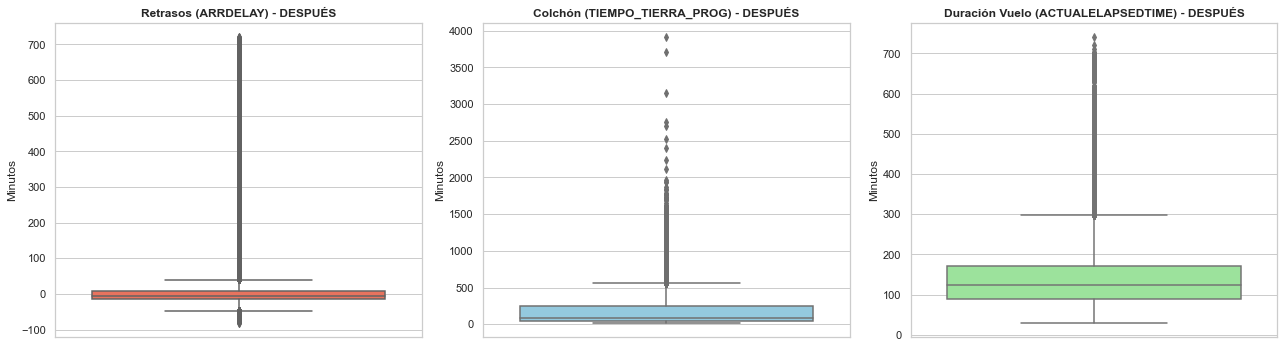

In [6]:
print("📊 AUDITORÍA: DIAGNÓSTICO VISUAL (DESPUÉS DE LA QUEMA)")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_theme(style="whitegrid")

# Gráfico 1: Retrasos Limpios
sns.boxplot(y=df_total['ARRDELAY'], ax=axes[0], color='tomato')
axes[0].set_title('Retrasos (ARRDELAY) - DESPUÉS', fontweight='bold')
axes[0].set_ylabel('Minutos')

# Gráfico 2: Colchón de Tierra Limpio
sns.boxplot(y=df_total['TIEMPO_TIERRA_PROG'], ax=axes[1], color='skyblue')
axes[1].set_title('Colchón (TIEMPO_TIERRA_PROG) - DESPUÉS', fontweight='bold')
axes[1].set_ylabel('Minutos')

# Gráfico 3: Duración Limpia
sns.boxplot(y=df_total['ACTUALELAPSEDTIME'], ax=axes[2], color='lightgreen')
axes[2].set_title('Duración Vuelo (ACTUALELAPSEDTIME) - DESPUÉS', fontweight='bold')
axes[2].set_ylabel('Minutos')

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd

print("📑 GENERANDO TABLAS PARA MEMORIA TFG (SECCIONES 4.2.3 Y 4.2.4)...\n")

# ==========================================
# 4.2.3 ANÁLISIS DE VALORES NULOS
# ==========================================
tabla_nulos = pd.DataFrame({
    'Valores Nulos': df_total.isnull().sum(),
    'Porcentaje de Nulos (%)': (df_total.isnull().sum() / len(df_total) * 100).round(2)
})

print("TABLA 1. Auditoría de Valores Nulos (Tras estandarización inicial)")
print("-" * 65)
display(tabla_nulos)
print("-" * 65)

📑 GENERANDO TABLAS PARA MEMORIA TFG (SECCIONES 4.2.3 Y 4.2.4)...

TABLA 1. Auditoría de Valores Nulos (Tras estandarización inicial)
-----------------------------------------------------------------


,Valores Nulos,Porcentaje de Nulos (%)
MONTH,0,0.00
DAYOFWEEK,0,0.00
FLIGHTDATE,0,0.00
REPORTING_AIRLINE,0,0.00
TAIL_NUMBER,0,0.00
ORIGIN,0,0.00
DEST,0,0.00
DEPDELAY,0,0.00
TAXIOUT,0,0.00
TAXIIN,0,0.00


-----------------------------------------------------------------


In [8]:
print("🩹 APLICANDO TRATAMIENTO DE NULOS EN CAUSAS DE RETRASO...")

# Definimos las variables con nulos
causas_retraso = ['CARRIERDELAY', 'WEATHERDELAY', 'NASDELAY', 'SECURITYDELAY', 'LATEAIRCRAFTDELAY']

# Rellenamos los NaNs con 0 (0 minutos de retraso por esa causa)
df_total[causas_retraso] = df_total[causas_retraso].fillna(0)

print("✅ Tratamiento completado: Los nulos de causas ahora son 0 minutos.")

🩹 APLICANDO TRATAMIENTO DE NULOS EN CAUSAS DE RETRASO...
✅ Tratamiento completado: Los nulos de causas ahora son 0 minutos.


In [9]:
vars_numericas_crudas = df_total[['DEPDELAY', 'ARRDELAY', 'ACTUALELAPSEDTIME', 'CRSELAPSEDTIME', 'DISTANCE', 'TAXIOUT', 'TAXIIN']]

tabla_desc = vars_numericas_crudas.describe().T
tabla_desc = tabla_desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
tabla_desc.columns = ['Cantidad', 'Media', 'Desviación Estándar', 'Mínimo', 'Percentil 25', 'Mediana', 'Percentil 75', 'Máximo']

tabla_desc['Cantidad'] = tabla_desc['Cantidad'].astype(int)
tabla_desc = tabla_desc.round(2)

print("\nTABLA 2. Análisis descriptivo de las variables principales")
print("-" * 105)
display(tabla_desc)
print("-" * 105)


TABLA 2. Análisis descriptivo de las variables principales
---------------------------------------------------------------------------------------------------------


,Cantidad,Media,Desviación Estándar,Mínimo,Percentil 25,Mediana,Percentil 75,Máximo
DEPDELAY,546343,8.65,38.26,-49.0,-6.0,-2.0,6.0,732.0
ARRDELAY,546343,3.28,40.83,-81.0,-15.0,-7.0,7.0,720.0
ACTUALELAPSEDTIME,546343,141.14,72.74,30.0,88.0,125.0,172.0,740.0
CRSELAPSEDTIME,546343,146.52,72.99,24.0,92.0,130.0,177.0,707.0
DISTANCE,546343,832.57,594.58,31.0,399.0,680.0,1068.0,5095.0
TAXIOUT,546343,17.32,8.80,1.0,12.0,15.0,20.0,176.0
TAXIIN,546343,8.02,6.13,1.0,4.0,6.0,10.0,175.0


---------------------------------------------------------------------------------------------------------


In [10]:
print("🌍 INGENIERÍA: CLASIFICACIÓN TÉCNICA DE AEROPUERTOS (CRITERIO FAA)...")

conteo_vuelos = df_total['ORIGIN'].value_counts().reset_index()
conteo_vuelos.columns = ['ORIGIN', 'VUELOS_TOTALES']

conteo_vuelos = conteo_vuelos.sort_values('VUELOS_TOTALES', ascending=False)
conteo_vuelos['PORCENTAJE_RED'] = (conteo_vuelos['VUELOS_TOTALES'] / conteo_vuelos['VUELOS_TOTALES'].sum()) * 100
conteo_vuelos['PORCENTAJE_ACUMULADO'] = conteo_vuelos['PORCENTAJE_RED'].cumsum()

def clasificar_faa(fila):
    if fila['PORCENTAJE_ACUMULADO'] <= 50:
        return 'LARGE_HUB'
    elif fila['PORCENTAJE_ACUMULADO'] <= 75:
        return 'MEDIUM_HUB'
    else:
        return 'REGIONAL'

conteo_vuelos['TIPO_AEROPUERTO'] = conteo_vuelos.apply(clasificar_faa, axis=1)
df_total = df_total.merge(conteo_vuelos[['ORIGIN', 'TIPO_AEROPUERTO']], on='ORIGIN', how='left')

print("✅ Contexto de Red inyectado. TIPO_AEROPUERTO creado.")

🌍 INGENIERÍA: CLASIFICACIÓN TÉCNICA DE AEROPUERTOS (CRITERIO FAA)...
✅ Contexto de Red inyectado. TIPO_AEROPUERTO creado.


In [11]:
print("📅 INGENIERÍA: INYECTANDO ESTACIONALIDAD Y FESTIVOS...")

# 1. Variables Temporales
df_total['HORA_SALIDA'] = df_total['SCHED_DEP'].dt.hour
df_total['DIA_SEMANA'] = df_total['SCHED_DEP'].dt.dayofweek

# 2. Variable Festivo (Fuerza Bruta de Alta Eficiencia)
festivos_2024 = [
    '2024-01-01', '2024-01-15', '2024-02-19', '2024-05-27', '2024-06-19'
]
festivos_dt = pd.to_datetime(festivos_2024)
df_total['ES_FESTIVO'] = df_total['FLIGHTDATE'].isin(festivos_dt).astype(int)

print("✅ Variables HORA_SALIDA, DIA_SEMANA y ES_FESTIVO creadas con éxito.")

📅 INGENIERÍA: INYECTANDO ESTACIONALIDAD Y FESTIVOS...
✅ Variables HORA_SALIDA, DIA_SEMANA y ES_FESTIVO creadas con éxito.


In [12]:
# 1. Aseguramos que FLIGHTDATE esté en formato datetime
# Esto permite que pandas entienda la fecha correctamente
df_total['FLIGHTDATE'] = pd.to_datetime(df_total['FLIGHTDATE'])

# 2. Calculamos la densidad de tráfico
# Agrupamos por Aeropuerto de Origen, Fecha y Hora Programada
# Usamos transform('count') para que el resultado se asigne a cada fila individualmente
df_total['DENSIDAD_TRAFICO_HORA'] = df_total.groupby(['ORIGIN', 'FLIGHTDATE', 'HORA_SALIDA'])['ORIGIN'].transform('count')



print("✅ Variable 'DENSIDAD_TRAFICO_HORA' calculada y dataset optimizado.")

✅ Variable 'DENSIDAD_TRAFICO_HORA' calculada y dataset optimizado.


In [13]:
print("🧩 INGENIERÍA: MIDIENDO LA TENSIÓN OPERATIVA Y EL FACTOR HUMANO...")

# 1. Secuencia de Vuelo (Orden estricto por avión y tiempo de salida)
df_total = df_total.sort_values(by=['TAIL_NUMBER', 'FULL_DATETIME_DEP'])
df_total['SECUENCIA_VUELO_DIA'] = df_total.groupby(['TAIL_NUMBER', 'FLIGHTDATE']).cumcount() + 1

# 2. Recuperación en Vuelo (El piloto Héroe)
df_total['RECUPERACION_VUELO'] = df_total['CRSELAPSEDTIME'] - df_total['ACTUALELAPSEDTIME']

print("✅ Variables SECUENCIA_VUELO_DIA y RECUPERACION_VUELO inyectadas.")

🧩 INGENIERÍA: MIDIENDO LA TENSIÓN OPERATIVA Y EL FACTOR HUMANO...
✅ Variables SECUENCIA_VUELO_DIA y RECUPERACION_VUELO inyectadas.


In [14]:
print("🎯 INGENIERÍA: ETIQUETADO DE NEGOCIO Y VARIABLE OBJETIVO...")

# 1. Categoría del Margen Operativo Neto 
# Esta la podemos dejar con 5 etiquetas porque es informativa/visual, no es el target
bins_margen = [-np.inf, 0, 30, 60, 120, np.inf]
etiquetas_margen = ['1. Negativo (Asfixia)', '2. Crítico (0-30m)', '3. Justo (30-60m)', '4. Holgado (1-2h)', '5. Sobrado (>2h)']
df_total['CATEGORIA_MARGEN'] = pd.cut(df_total['MARGEN_OPERATIVO_NETO'], bins=bins_margen, labels=etiquetas_margen)

# 2. Variable Objetivo: Rango de Retraso de Salida (Target) -> ¡AQUÍ EL CAMBIO A 3 CLASES!
bins_retraso = [-np.inf, 15, 60, np.inf]
etiquetas_retraso = ['0_A_Tiempo', '1_Leve', '2_Grave']
df_total['RANGO_RETRASO'] = pd.cut(df_total['DEPDELAY'], bins=bins_retraso, labels=etiquetas_retraso)

print("✅ Categorías de Margen y Variable Objetivo (3 CLASES) creadas. Ingeniería de datos FINALIZADA.")

🎯 INGENIERÍA: ETIQUETADO DE NEGOCIO Y VARIABLE OBJETIVO...
✅ Categorías de Margen y Variable Objetivo (3 CLASES) creadas. Ingeniería de datos FINALIZADA.


In [21]:
df_total.head(30)

,MONTH,DAYOFWEEK,FLIGHTDATE,REPORTING_AIRLINE,TAIL_NUMBER,ORIGIN,DEST,DEPDELAY,TAXIOUT,TAXIIN,...,TIPO_AEROPUERTO,HORA_SALIDA,DIA_SEMANA,ES_FESTIVO,DENSIDAD_TRAFICO_HORA,SECUENCIA_VUELO_DIA,RECUPERACION_VUELO,CATEGORIA_MARGEN,RANGO_RETRASO,SALIDA_TARDIA
0,4,1,2024-04-01,G4,188NV,PGD,PSM,-5.0,9.0,5.0,...,REGIONAL,6,0,0,2,1,-5.0,NaN,0_A_Tiempo,0
1,4,1,2024-04-01,G4,188NV,PSM,PGD,20.0,68.0,7.0,...,REGIONAL,10,0,0,1,2,-27.0,3. Justo (30-60m),1_Leve,1
2,4,1,2024-04-01,G4,188NV,PGD,SPI,9.0,16.0,68.0,...,REGIONAL,15,0,0,2,3,-64.0,4. Holgado (1-2h),0_A_Tiempo,0
3,4,1,2024-04-01,G4,188NV,SPI,PGD,69.0,11.0,6.0,...,REGIONAL,18,0,0,1,4,4.0,NaN,2_Grave,1
4,4,2,2024-04-02,G4,188NV,PGD,ALB,-11.0,16.0,7.0,...,REGIONAL,10,1,0,2,1,-4.0,NaN,0_A_Tiempo,0
5,4,2,2024-04-02,G4,188NV,ALB,PGD,2.0,12.0,6.0,...,REGIONAL,14,1,0,2,2,3.0,3. Justo (30-60m),0_A_Tiempo,0
6,4,3,2024-04-03,G4,188NV,PGD,PSM,-5.0,12.0,5.0,...,REGIONAL,9,2,0,3,1,21.0,NaN,0_A_Tiempo,0
7,4,3,2024-04-03,G4,188NV,PSM,PGD,74.0,49.0,7.0,...,REGIONAL,13,2,0,1,2,-73.0,4. Holgado (1-2h),2_Grave,1
8,4,4,2024-04-04,G4,188NV,PGD,PBG,-6.0,10.0,4.0,...,REGIONAL,7,3,0,4,1,22.0,5. Sobrado (>2h),0_A_Tiempo,0
9,4,4,2024-04-04,G4,188NV,PBG,PGD,0.0,56.0,7.0,...,REGIONAL,11,3,0,2,2,-43.0,4. Holgado (1-2h),0_A_Tiempo,0


📊 EDA 1: DISTRIBUCIÓN GLOBAL DE RETRASOS


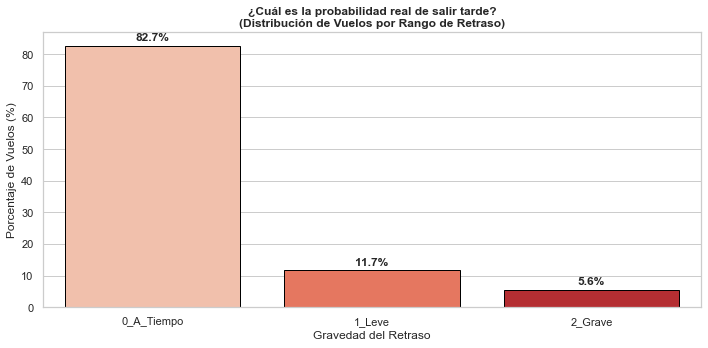

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 EDA 1: DISTRIBUCIÓN GLOBAL DE RETRASOS")

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

distribucion = df_total['RANGO_RETRASO'].value_counts(normalize=True).sort_index() * 100

ax = sns.barplot(x=distribucion.index, y=distribucion.values, palette='Reds', edgecolor='black')
plt.title('¿Cuál es la probabilidad real de salir tarde?\n(Distribución de Vuelos por Rango de Retraso)', fontweight='bold')
plt.ylabel('Porcentaje de Vuelos (%)')
plt.xlabel('Gravedad del Retraso')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

📊 EDA 2: EL EFECTO DOMINÓ (MARGEN VS PROBABILIDAD DE RETRASO)


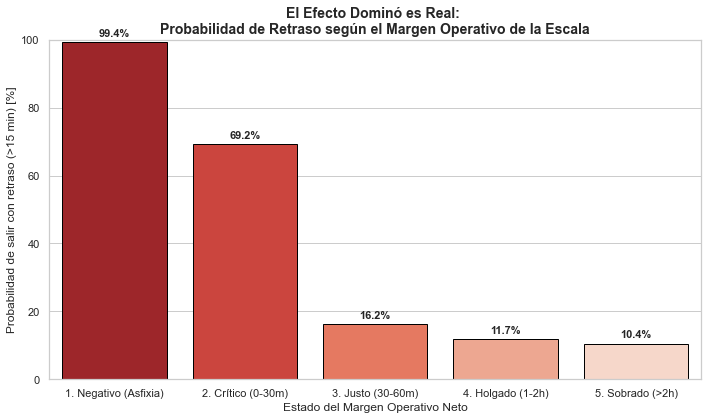


💡 INSIGHT CRUDO:
Margen negativo: 99.4% probabilidad de salir tarde.
Margen sobrado: 10.4% probabilidad de salir tarde.


In [17]:
print("📊 EDA 2: EL EFECTO DOMINÓ (MARGEN VS PROBABILIDAD DE RETRASO)")

# 1. Definimos qué es salir tarde para el negocio (Ej: más de 15 minutos)
df_total['SALIDA_TARDIA'] = (df_total['DEPDELAY'] > 15).astype(int)

# 2. Filtramos los NaNs (inicios de jornada) para centrarnos en las rotaciones
df_rotaciones = df_total.dropna(subset=['MARGEN_OPERATIVO_NETO']).copy()

# 3. Probabilidad de salir tarde según cómo de asfixiado va el vuelo
probabilidad_retraso = df_rotaciones.groupby('CATEGORIA_MARGEN')['SALIDA_TARDIA'].mean() * 100

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=probabilidad_retraso.index, y=probabilidad_retraso.values, palette='Reds_r', edgecolor='black')

plt.title('El Efecto Dominó es Real: \nProbabilidad de Retraso según el Margen Operativo de la Escala', fontsize=14, fontweight='bold')
plt.xlabel('Estado del Margen Operativo Neto', fontsize=12)
plt.ylabel('Probabilidad de salir con retraso (>15 min) [%]', fontsize=12)
plt.ylim(0, 100)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), textcoords = 'offset points',
                fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print("\n💡 INSIGHT CRUDO:")
print(f"Margen negativo: {probabilidad_retraso.iloc[0]:.1f}% probabilidad de salir tarde.")
print(f"Margen sobrado: {probabilidad_retraso.iloc[-1]:.1f}% probabilidad de salir tarde.")

⏰ EDA 3: EL ENVEJECIMIENTO DEL DÍA OPERATIVO


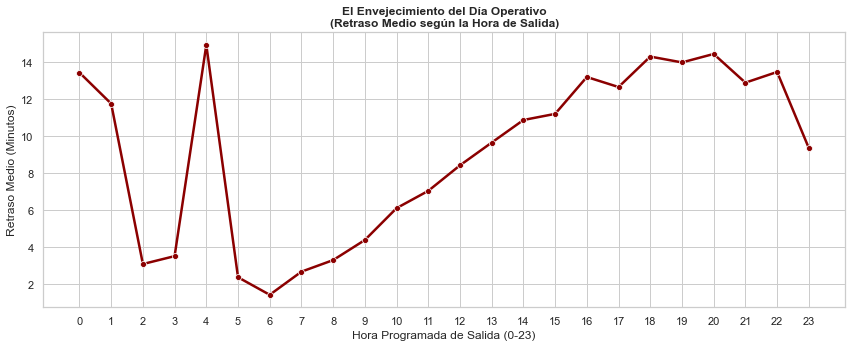

💡 INSIGHT: A las 08:00 AM el retraso medio es de 3.3 mins. A las 20:00 PM se dispara a 14.5 mins.


In [18]:
print("⏰ EDA 3: EL ENVEJECIMIENTO DEL DÍA OPERATIVO")

plt.figure(figsize=(12, 5))

# Nota: Usamos ci=None por compatibilidad con tu versión de Seaborn
ax = sns.lineplot(data=df_total, x='HORA_SALIDA', y='DEPDELAY', 
                  marker='o', color='darkred', linewidth=2.5, ci=None)

plt.title('El Envejecimiento del Día Operativo\n(Retraso Medio según la Hora de Salida)', fontweight='bold')
plt.xlabel('Hora Programada de Salida (0-23)')
plt.ylabel('Retraso Medio (Minutos)')
plt.xticks(range(0, 24))

plt.tight_layout()
plt.show()

retraso_mañana = df_total[df_total['HORA_SALIDA'] == 8]['DEPDELAY'].mean()
retraso_noche = df_total[df_total['HORA_SALIDA'] == 20]['DEPDELAY'].mean()
print(f"💡 INSIGHT: A las 08:00 AM el retraso medio es de {retraso_mañana:.1f} mins. A las 20:00 PM se dispara a {retraso_noche:.1f} mins.")

In [19]:
print("🗄️ EDA 4: IMPACTO DEL CALENDARIO (DATOS CRUDOS PARA MEMORIA)")

# Tabla Meses
tabla_meses = df_total.groupby('MONTH').agg(
    TOTAL_VUELOS=('DEPDELAY', 'count'),
    RETRASO_MEDIO_MIN=('DEPDELAY', 'mean'),
    RETRASO_MEDIANO_MIN=('DEPDELAY', 'median')
).copy()

vuelos_crisis_mes = df_total[df_total['RANGO_RETRASO'] == '4_Crisis'].groupby('MONTH').size()
tabla_meses['%_VUELOS_EN_CRISIS'] = (vuelos_crisis_mes / tabla_meses['TOTAL_VUELOS']) * 100
tabla_meses = tabla_meses.round(2)

print("\n📅 TABLA 1: IMPACTO MENSUAL EXACTO")
print("-" * 65)
print(tabla_meses.to_string())

# Tabla Festivos
tabla_festivos = df_total.groupby('ES_FESTIVO').agg(
    TOTAL_VUELOS=('DEPDELAY', 'count'),
    RETRASO_MEDIO_MIN=('DEPDELAY', 'mean'),
    RETRASO_MEDIANO_MIN=('DEPDELAY', 'median')
).copy()

vuelos_crisis_festivo = df_total[df_total['RANGO_RETRASO'] == '4_Crisis'].groupby('ES_FESTIVO').size()
tabla_festivos['%_VUELOS_EN_CRISIS'] = (vuelos_crisis_festivo / tabla_festivos['TOTAL_VUELOS']) * 100
tabla_festivos.index = ['0 (Día Normal)', '1 (Festivo)']
tabla_festivos = tabla_festivos.round(2)

print("\n🎉 TABLA 2: IMPACTO DE FESTIVOS FEDERALES EXACTO")
print("-" * 65)
print(tabla_festivos.to_string())

🗄️ EDA 4: IMPACTO DEL CALENDARIO (DATOS CRUDOS PARA MEMORIA)

📅 TABLA 1: IMPACTO MENSUAL EXACTO
-----------------------------------------------------------------
       TOTAL_VUELOS  RETRASO_MEDIO_MIN  RETRASO_MEDIANO_MIN  %_VUELOS_EN_CRISIS
MONTH                                                                          
4            546343               8.65                 -2.0                 NaN


ValueError: Length mismatch: Expected axis has 1 elements, new values have 2 elements

In [ ]:
print("🔍 EDA 5: AUTOPSIA DE CAUSAS DE RETRASO")

causas = ['CARRIERDELAY', 'WEATHERDELAY', 'NASDELAY', 'SECURITYDELAY', 'LATEAIRCRAFTDELAY']
df_causas = df_total[['MONTH'] + causas].copy().fillna(0)

tabla_medias_causas = df_causas.groupby('MONTH')[causas].mean()
suma_mensual_causas = tabla_medias_causas.sum(axis=1)
tabla_pct_causas = tabla_medias_causas.div(suma_mensual_causas, axis=0) * 100

colores_causas = ['#440154', '#3b528b', '#21918c', '#5ec962', '#fde725']
ax = tabla_pct_causas.plot(kind='bar', stacked=True, figsize=(12, 7), color=colores_causas, edgecolor='white')

plt.title('Distribución de Culpabilidad en el Retraso (Enero - Junio 2024)\nEl Dominio del Efecto Dominó (Late Aircraft Delay)', fontsize=14, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Porcentaje del Retraso Total (%)', fontsize=12)
plt.legend(title='Causa Oficial', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

peso_domino = tabla_pct_causas['LATEAIRCRAFTDELAY'].mean()
print(f"💡 INSIGHT: El Efecto Dominó absorbe un {peso_domino:.1f}% del total de los retrasos.")

In [ ]:
print("🏟️ EDA 6: RESILIENCIA DE LA RED (HUBs vs REGIONALES)")

resumen_aeropuertos = df_total.groupby('TIPO_AEROPUERTO').agg(
    TOTAL_VUELOS=('DEPDELAY', 'count'),
    RETRASO_MEDIO=('DEPDELAY', 'mean'),
    MARGEN_MEDIO=('MARGEN_OPERATIVO_NETO', 'mean'),
    _CRISIS=('RANGO_RETRASO', lambda x: (x == '4_Crisis').mean() * 100)
).round(2)

print("\n📊 TABLA COMPARATIVA: EL COMPORTAMIENTO DE LA RED")
print("-" * 75)
print(resumen_aeropuertos.to_string())

plt.figure(figsize=(12, 6))
sns.violinplot(data=df_total, x='TIPO_AEROPUERTO', y='MARGEN_OPERATIVO_NETO', palette='muted', split=True)
plt.axhline(0, color='red', linestyle='--', alpha=0.6)
plt.title('Distribución del Margen Operativo por Tipo de Aeropuerto', fontweight='bold')
plt.ylabel('Margen Operativo Neto (Min)')
plt.ylim(-60, 150)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=df_total, x='TIPO_AEROPUERTO', y='DEPDELAY', hue='ES_FESTIVO', palette='magma', ci=None)
plt.title('Retraso Medio: HUB vs Regional (Días Normales vs Festivos)', fontweight='bold')
plt.ylabel('Retraso Medio de Salida (Min)')
plt.show()

In [ ]:
print("🧪 EDA 7: MATRIZ DE CORRELACIÓN FINAL")

cols_analisis = [
    'DEPDELAY', 'MARGEN_OPERATIVO_NETO', 'RETRASO_HEREDADO_REAL', 
    'TIEMPO_TIERRA_PROG', 'SECUENCIA_VUELO_DIA', 'ES_FESTIVO', 
    'DISTANCE','DENSIDAD_TRAFICO_HORA'
]

corr = df_total[cols_analisis].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación: ¿Qué variables "mandan" en el retraso?', fontweight='bold')
plt.show()

In [ ]:
df_total.head()

In [ ]:
print("🧹 INICIANDO PURGA FINAL: ELIMINACIÓN DE VENENO Y GRASA...")

columnas_basura = [
    # Data Leakage (El Veneno)
    'TAXIOUT', 'TAXIIN', 'ARRDELAY', 'ARRDEL15', 'ACTUALELAPSEDTIME', 
    'CARRIERDELAY', 'WEATHERDELAY', 'NASDELAY', 'SECURITYDELAY', 
    'LATEAIRCRAFTDELAY', 'RECUPERACION_VUELO',
    
    # Redundancia y variables visuales (La Grasa)
    'DAYOFWEEK', 'TIEMPO_TIERRA_PROG', 'CATEGORIA_MARGEN', 'SALIDA_TARDIA', 
    'CRSELAPSEDTIME',
    
    # Formatos Datetime (El Lastre)
    'FLIGHTDATE', 'SCHED_DEP', 'FULL_DATETIME_DEP', 'SCHED_ARR', 'FULL_DATETIME_ARR'
]

# Ejecutamos la eliminación
df_gold = df_total.drop(columns=columnas_basura, errors='ignore').copy()

print(f"✅ PURGA COMPLETADA.")
print(f"Has pasado de 36 variables a un dataset puro de {df_gold.shape[1]} columnas.")
print("\n📊 VARIABLES PREDICTORAS FINALES:")
print(df_gold.columns.tolist())

# Guardado Maestro
ruta_guardado_csv = '/Users/manuelgonzalez/Documents/Documentos TFG/dataset_tfg_limpio.csv'

# Guardamos el CSV. Tardará un poco más y pesará más, pero funciona al 100%.
df_gold.to_csv(ruta_guardado_csv, index=False)

print(f"\n💾 ¡ÉXITO! Dataset final guardado de forma segura en:")
print(f"📁 {ruta_guardado_csv}")
print("⚠️ ADVERTENCIA: En el nuevo cuaderno, habrá que redefinir las categorías (RANGO_RETRASO).")